## Calculation for the discussion (misalignment angle) Figure 11 from the paper

In [4]:
import numpy as np
import os
import matplotlib.pyplot as plt
from field_decay.compact_objects import NS
home = os.path.expanduser("~")
file = f"{home}/.config/matplotlib/stylelib/paper.mplstyle"
if os.path.exists(file):
    plt.style.use(file)
from matplotlib.ticker import FuncFormatter

def format_tick(x, pos):
    return f'{int(x)}' if x == int(x) else f'{x}'

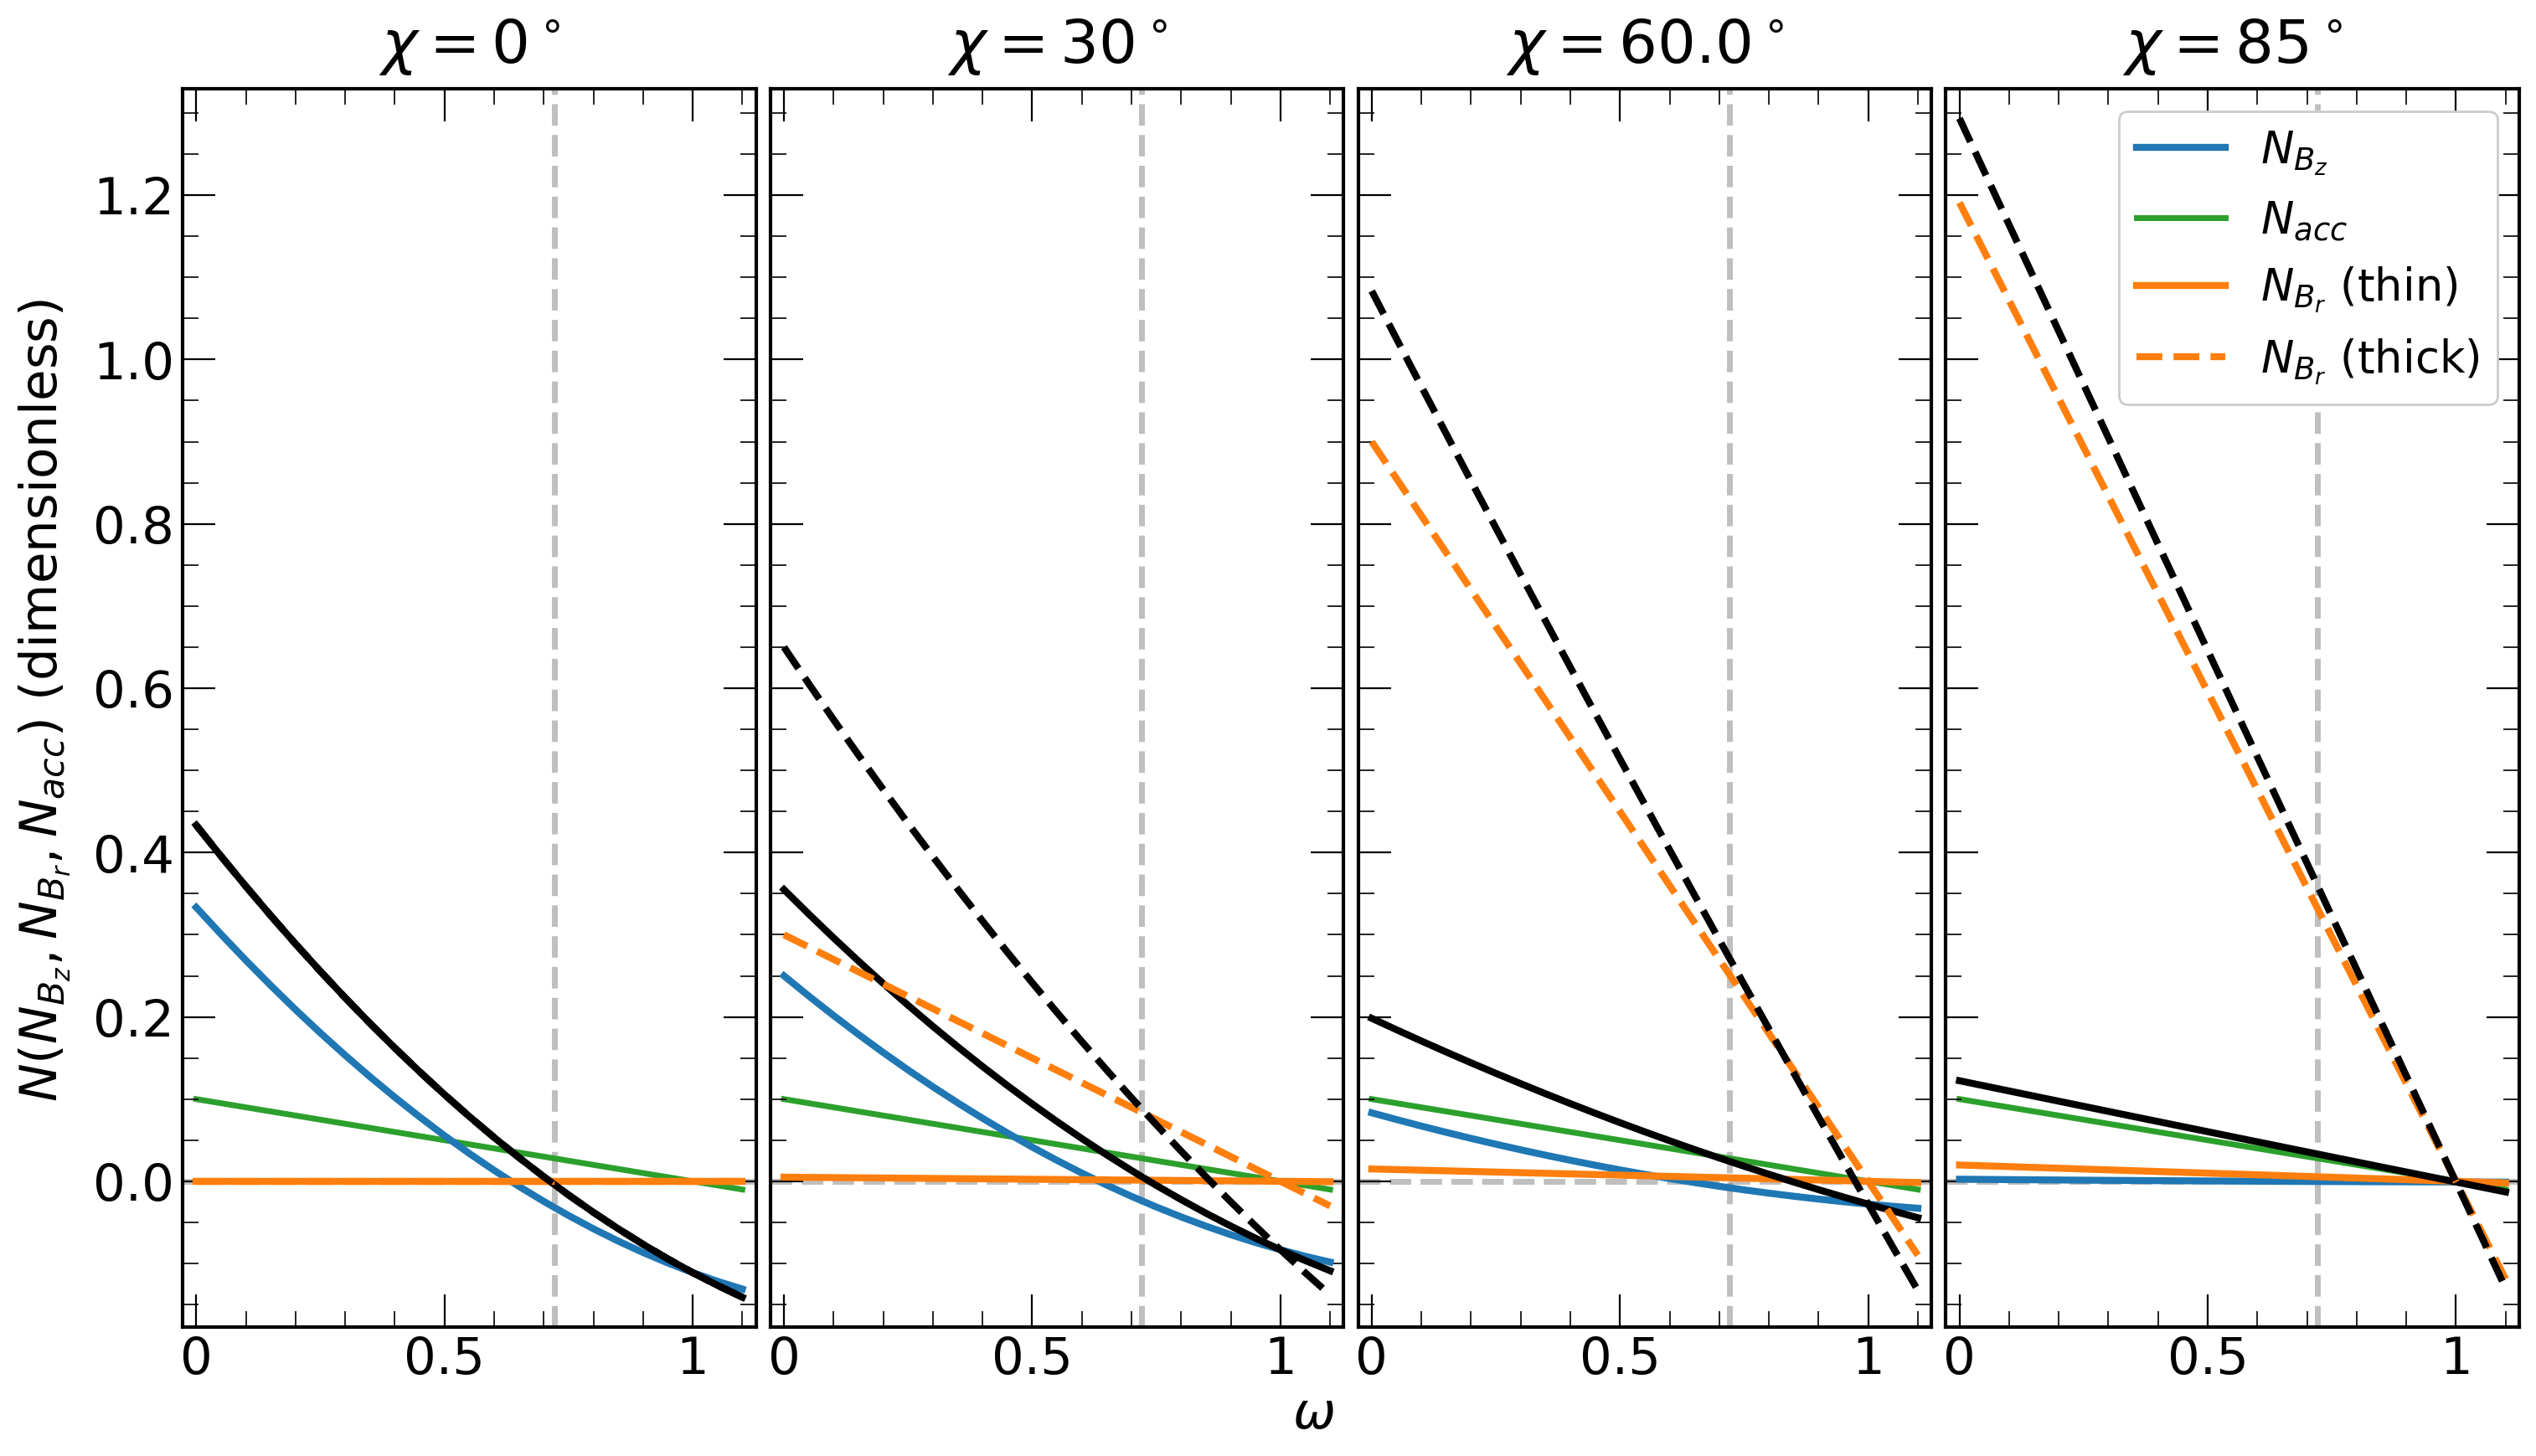

In [5]:
chis = [0, 30, 60.0, 85]
delta = 0.1
fig, axes = plt.subplots(1, len(chis), figsize=(18, 9.6), 
                         sharex=True, sharey=True, gridspec_kw={"hspace": 0.00, "wspace": 0.025})

w = np.arange(0, 1.15, 0.05)
ls = ['-', '--']
Nacc = delta * (1 - w)
for ax, chi in zip(axes, chis):
    N_z = np.cos(chi * np.pi / 180)**2 * (1/3 -2/3 *w + 2/9*w**2)
    ax.plot(w, N_z, label='$N_{B_z}$', linestyle="-", color='C0', lw=3)
    ax.plot(w, Nacc, label='$N_{acc}$', linestyle="-", color='C2', zorder=-8, lw=2.5)
    ax.xaxis.set_major_formatter(FuncFormatter(format_tick))
    ax.axhline(0., ls="--" , color='grey', zorder=-10, alpha=0.5)
    ax.axvline(0.721, ls="--" , color='grey', zorder=-10, alpha=0.5)

    for h_0, l in zip([0.01, 0.6], ls):
        N_r = 2 * h_0 * np.sin(chi * np.pi / 180)**2 * (1 - w)
        nr_label = '$N_{B_r}$ (thin)' if h_0 == 0.01 else '$N_{B_r}$ (thick)'
        total_label = '$N_{B_z} + N_{B_r} + N_{acc}$' if h_0 == 0.7 else None
        ax.plot(w, N_r, label=nr_label, linestyle=l, color='C1', lw=3)
        ax.plot(w, N_z + N_r + Nacc, label=total_label, linestyle=l, color='black', lw=3)
    
    ax.set_title(r"$\chi = {}^\circ$".format(chi), y=1.01)
plt.legend(frameon=True, framealpha=1)
fig.supxlabel(r"$\omega$", y=0.04, fontsize=22)
fig.supylabel(r"$N (N_{B_z}, N_{B_r}, N_{acc})$ (dimensionless)", x=0.07, fontsize=22)
plt.savefig("inclined_torque")